In [1]:
## Optimization using Gradient Descent
## Linear Regression

## build a simple linear regression model
# to predict 
import numpy as np
# A library for programmatic plot generation.
import matplotlib.pyplot as plt
# A library for data manipulation and analysis.
import pandas as pd
# LinearRegression from sklearn.
from sklearn.linear_model import LinearRegression

In [2]:
import w2_unittest

In [5]:
adv = pd.read_csv("tvmarketing.csv")
adv.head() # tv marketing expenses, sales amount

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [6]:
w2_unittest.test_load_data(adv)

 All tests passed


<AxesSubplot:xlabel='TV', ylabel='Sales'>

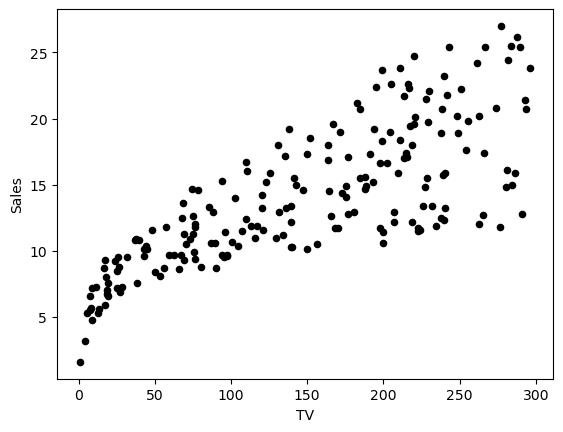

In [7]:
adv.plot(x='TV', y='Sales', kind='scatter', c='black')

In [8]:
# linear regression in python
# with numpy and scikit-learn

X = adv['TV']
Y = adv['Sales']

In [11]:
m_numpy, b_numpy = np.polyfit(X, Y, 1)

print(f"Linear regression with NumPy. Slope: {m_numpy}. Intercept: {b_numpy}")

Linear regression with NumPy. Slope: 0.04753664043301971. Intercept: 7.032593549127703


In [12]:
def pred_numpy(m, b, X):
    Y = m * X + b
    return Y

X_pred = np.array([50, 120, 280])
Y_pred_numpy = pred_numpy(m_numpy, b_numpy, X_pred)

print(f"TV marketing expenses:\n{X_pred}")
print(f"Predictions of sales using NumPy linear regression:\n{Y_pred_numpy}")

TV marketing expenses:
[ 50 120 280]
Predictions of sales using NumPy linear regression:
[ 9.40942557 12.7369904  20.34285287]


In [13]:
w2_unittest.test_pred_numpy(pred_numpy)

 All tests passed


In [14]:
## linear regression with scikiet-learn
lr_sklearn = LinearRegression()

In [15]:
X_sklearn = X[:, np.newaxis]
Y_sklearn = Y[:, np.newaxis]

print(f"Shape of new X array: {X_sklearn.shape}")
print(f"Shape of new Y array: {Y_sklearn.shape}")

Shape of new X array: (200, 1)
Shape of new Y array: (200, 1)


/var/folders/5s/qy4tg69s0gj605hvdynvvy4r0000gn/T/ipykernel_9108/3728240640.py:1: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  X_sklearn = X[:, np.newaxis]
/var/folders/5s/qy4tg69s0gj605hvdynvvy4r0000gn/T/ipykernel_9108/3728240640.py:2: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  Y_sklearn = Y[:, np.newaxis]


In [16]:
lr_sklearn.fit(X_sklearn, Y_sklearn)

LinearRegression()

In [17]:
m_sklearn = lr_sklearn.coef_
b_sklearn = lr_sklearn.intercept_

print(f"Linear regression using Scikit-Learn. Slope: {m_sklearn}. Intercept: {b_sklearn}")

Linear regression using Scikit-Learn. Slope: [[0.04753664]]. Intercept: [7.03259355]


In [18]:
w2_unittest.test_sklearn_fit(lr_sklearn)

 All tests passed


In [19]:
def pred_sklearn(X, lr_sklearn):
    ### START CODE HERE ### (~ 2 lines of code)
    X_2D = X[:, np.newaxis]
    Y = lr_sklearn.predict(X_2D)
    ### END CODE HERE ###
    
    return Y

In [20]:
Y_pred_sklearn = pred_sklearn(X_pred, lr_sklearn)

print(f"TV marketing expenses:\n{X_pred}")
print(f"Predictions of sales using Scikit_Learn linear regression:\n{Y_pred_sklearn.T}")

TV marketing expenses:
[ 50 120 280]
Predictions of sales using Scikit_Learn linear regression:
[[ 9.40942557 12.7369904  20.34285287]]


In [21]:
w2_unittest.test_sklearn_predict(pred_sklearn, lr_sklearn)

 All tests passed


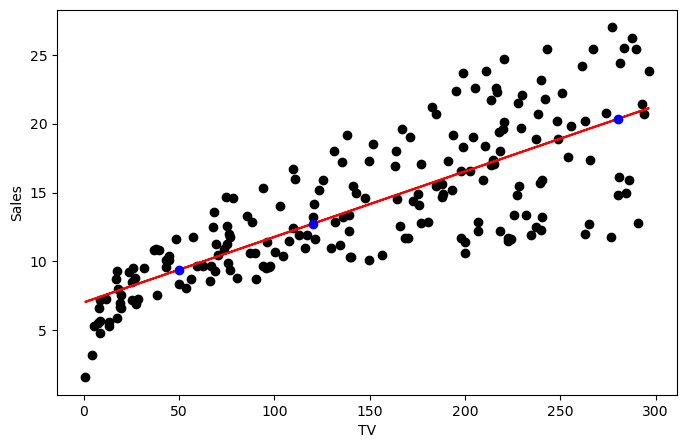

In [22]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
ax.plot(X, Y, 'o', color='black')
ax.set_xlabel('TV')
ax.set_ylabel('Sales')

ax.plot(X, m_sklearn[0][0]*X+b_sklearn[0], color='red')
ax.plot(X_pred, Y_pred_sklearn, 'o', color='blue')

In [24]:
## linear regression using tool
## linear regression using gradient descent
print(X.shape)
print(Y.shape)

(200,)
(200,)


In [38]:
# linear regression
# loss function
# E(m,b) = 1 / 2 * n  * np.sum(m *x + b - y)**2

# E/m, E/b

X_norm = (X - np.mean(X)) / np.std(X)
Y_norm = (Y - np.mean(Y)) / np.std(Y)

In [39]:
def E(m, b, X, Y):
    return 1/(2*len(Y))*np.sum((m*X + b - Y)**2)

In [40]:
# derivatives of m and b
def dEdm(m, b, X, Y):
    ### START CODE HERE ### (~ 1 line of code)
    # Use the following line as a hint, replacing all None.
    res = 1/len(Y)*np.dot(m*X + b - Y, X)
    ### END CODE HERE ###
    
    return res
    

def dEdb(m, b, X, Y):
    ### START CODE HERE ### (~ 1 line of code)
    # Replace None writing the required expression fully.
    res = 1/len(Y)*np.sum(m*X + b - Y)
    ### END CODE HERE ###
    
    return res

In [41]:
print(dEdm(0, 0, X_norm, Y_norm))
print(dEdb(0, 0, X_norm, Y_norm))
print(dEdm(1, 5, X_norm, Y_norm))
print(dEdb(1, 5, X_norm, Y_norm))

-0.7822244248616064
1.6431300764452317e-16
0.21777557513839377
5.000000000000001


In [42]:
def gradient_descent(dEdm, dEdb, m, b, X, Y, learning_rate = 0.001, num_iterations = 1000, print_cost=False):
    for iteration in range(num_iterations):
        ### START CODE HERE ### (~ 2 lines of code)
        m_new = m - learning_rate * dEdm(m, b, X, Y)
        b_new = b - learning_rate * dEdb(m, b, X, Y)
        ### END CODE HERE ###
        m = m_new
        b = b_new
        if print_cost:
            print (f"Cost after iteration {iteration}: {E(m, b, X, Y)}")
        
    return m, b

In [43]:
print(gradient_descent(dEdm, dEdb, 0, 0, X_norm, Y_norm))
print(gradient_descent(dEdm, dEdb, 1, 5, X_norm, Y_norm, learning_rate = 0.01, num_iterations = 10))

(0.4946040826958949, -1.3736567439082102e-16)
(0.9791767513915026, 4.521910375044022)


In [44]:
m_initial = 0; b_initial = 0; num_iterations = 30; learning_rate = 1.2
m_gd, b_gd = gradient_descent(dEdm, dEdb, m_initial, b_initial, 
                              X_norm, Y_norm, learning_rate, num_iterations, print_cost=True)

print(f"Gradient descent result: m_min, b_min = {m_gd}, {b_gd}") 

Cost after iteration 0: 0.2062999755919659
Cost after iteration 1: 0.19455197461564464
Cost after iteration 2: 0.19408205457659175
Cost after iteration 3: 0.19406325777502964
Cost after iteration 4: 0.19406250590296714
Cost after iteration 5: 0.1940624758280847
Cost after iteration 6: 0.19406247462508938
Cost after iteration 7: 0.19406247457696957
Cost after iteration 8: 0.19406247457504477
Cost after iteration 9: 0.19406247457496775
Cost after iteration 10: 0.1940624745749647
Cost after iteration 11: 0.19406247457496456
Cost after iteration 12: 0.19406247457496456
Cost after iteration 13: 0.1940624745749646
Cost after iteration 14: 0.19406247457496456
Cost after iteration 15: 0.19406247457496456
Cost after iteration 16: 0.19406247457496456
Cost after iteration 17: 0.19406247457496456
Cost after iteration 18: 0.19406247457496456
Cost after iteration 19: 0.19406247457496456
Cost after iteration 20: 0.19406247457496456
Cost after iteration 21: 0.19406247457496456
Cost after iteration 22: